# inference_comparison

The repo's code, collected into one notebook. Cells are verbatim copies of the
source files, in dependency order.

Run this notebook with its working directory set to `inference_comparison/` so the
`from shared...` imports in the check cells resolve.

## `shared/__init__.py`

Package glue — relative imports, so it is shown rather than executed:

```python
from .mini_llm import (TinyLLM, TinyLLMConfig, ByteTokenizer, SeqContext,
                       causal_attention, greedy, sample, DenseBackend)
from .regex_fsm import RegexFSM
```

## `shared/mini_llm.py`

In [1]:
"""
shared/mini_llm.py
==================
A *tiny*, randomly-initialised decoder-only Transformer used by BOTH the
vLLM-replica and the SGLang-replica.

There is deliberately **no model download and no external tokenizer**:
    * weights are random (torch default init) + a fixed seed for reproducibility,
    * the tokenizer is byte-level (vocab = 256, id == byte value).

The generated *text* is therefore meaningless. That is fine: these projects
replicate the *serving-engine mechanisms*, not model quality. Every mechanism
is validated on its own terms (see each demo's asserts).

The one important design choice: attention is delegated to a pluggable
`AttentionBackend`. The SAME `TinyLLM` runs under vLLM's PagedAttention backend
and under SGLang's RadixAttention backend -- exactly like a real engine swapping
its KV-cache/attention backend under a fixed model.
"""
from __future__ import annotations
import math
from dataclasses import dataclass, field
from typing import Protocol, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F


# --------------------------------------------------------------------------- #
# Tokenizer (byte-level, no files)                                            #
# --------------------------------------------------------------------------- #
class ByteTokenizer:
    """Maps a str <-> list[int] using raw UTF-8 bytes. vocab_size == 256.

    Token id 0 doubles as our EOS marker in demos (the NUL byte is never
    produced from normal text, so it is safe to reserve)."""
    vocab_size = 256
    eos_id = 0

    def encode(self, text: str) -> list[int]:
        return list(text.encode("utf-8"))

    def decode(self, ids: list[int]) -> str:
        return bytes(i for i in ids if i != self.eos_id).decode("utf-8", "replace")


# --------------------------------------------------------------------------- #
# Config                                                                       #
# --------------------------------------------------------------------------- #
@dataclass
class TinyLLMConfig:
    vocab_size: int = 256
    n_layer: int = 2
    n_head: int = 4
    d_head: int = 16
    d_ff: int = 256
    max_seq: int = 1024
    seed: int = 0

    @property
    def d_model(self) -> int:
        return self.n_head * self.d_head


# --------------------------------------------------------------------------- #
# Attention backend protocol                                                   #
# --------------------------------------------------------------------------- #
@dataclass
class SeqContext:
    """Per-sequence bookkeeping passed into the model on every forward step.

    seq_id       : unique id of the running sequence
    start_pos    : absolute position of the FIRST token in this step's input
                   (== number of tokens already committed to the KV cache)
    """
    seq_id: int
    start_pos: int
    extra: dict = field(default_factory=dict)


class AttentionBackend(Protocol):
    """A backend owns the KV cache and computes attention.

    Contract for `attention`:
      * inputs q,k,v have shape [T, n_head, d_head]  (T = tokens in this step)
      * the backend must (1) append k,v for these T tokens to its cache for
        `ctx.seq_id` at `layer_idx`, then (2) return attention output of shape
        [T, d_model], where each of the T query rows attends causally over the
        full history (cached prefix + the new tokens up to and including itself).
    """
    def attention(self, layer_idx: int, q: torch.Tensor, k: torch.Tensor,
                  v: torch.Tensor, ctx: SeqContext) -> torch.Tensor: ...


# --------------------------------------------------------------------------- #
# The shared attention math (used by every backend after it gathers K/V)       #
# --------------------------------------------------------------------------- #
def causal_attention(q: torch.Tensor, k_all: torch.Tensor, v_all: torch.Tensor,
                     n_prefix: int) -> torch.Tensor:
    """Multi-head causal attention.

    q      : [T, H, D]   queries for the T new tokens
    k_all  : [P+T, H, D] keys for prefix (P) + new (T) tokens
    v_all  : [P+T, H, D]
    n_prefix (P): number of cached prefix tokens (query i may see all P of them
                  plus new tokens j <= i).

    Returns [T, H*D].
    """
    T, H, D = q.shape
    L = k_all.shape[0]
    P = n_prefix
    assert L == P + T, f"expected {P}+{T} keys, got {L}"

    # [H, T, D] x [H, D, L] -> [H, T, L]
    qh = q.permute(1, 0, 2)                      # [H, T, D]
    kh = k_all.permute(1, 2, 0)                  # [H, D, L]
    scores = torch.matmul(qh, kh) / math.sqrt(D) # [H, T, L]

    # causal mask: new query i (abs pos P+i) may attend to key at abs pos <= P+i
    key_pos = torch.arange(L)                    # 0..L-1  == absolute positions
    qry_pos = torch.arange(P, P + T).unsqueeze(1)  # [T,1]
    allowed = key_pos.unsqueeze(0) <= qry_pos    # [T, L]
    scores = scores.masked_fill(~allowed.unsqueeze(0), float("-inf"))

    probs = torch.softmax(scores, dim=-1)        # [H, T, L]
    vh = v_all.permute(1, 0, 2)                  # [H, L, D]
    out = torch.matmul(probs, vh)                # [H, T, D]
    return out.permute(1, 0, 2).reshape(T, H * D)


# --------------------------------------------------------------------------- #
# Model                                                                        #
# --------------------------------------------------------------------------- #
class TinyBlock(nn.Module):
    def __init__(self, cfg: TinyLLMConfig):
        super().__init__()
        d = cfg.d_model
        self.n_head, self.d_head = cfg.n_head, cfg.d_head
        self.ln1 = nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3 * d)
        self.proj = nn.Linear(d, d)
        self.ln2 = nn.LayerNorm(d)
        self.mlp = nn.Sequential(nn.Linear(d, cfg.d_ff), nn.GELU(),
                                 nn.Linear(cfg.d_ff, d))

    def forward(self, layer_idx, h, backend: AttentionBackend, ctx: SeqContext):
        T = h.shape[0]
        x = self.ln1(h)
        q, k, v = self.qkv(x).split(h.shape[-1], dim=-1)
        shp = (T, self.n_head, self.d_head)
        q, k, v = q.view(shp), k.view(shp), v.view(shp)
        attn = backend.attention(layer_idx, q, k, v, ctx)  # [T, d_model]
        h = h + self.proj(attn)
        h = h + self.mlp(self.ln2(h))
        return h


class TinyLLM(nn.Module):
    def __init__(self, cfg: TinyLLMConfig):
        super().__init__()
        torch.manual_seed(cfg.seed)
        self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.pos_emb = nn.Embedding(cfg.max_seq, cfg.d_model)
        self.layers = nn.ModuleList([TinyBlock(cfg) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.lm_head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.eval()  # inference-only replicas

    @torch.no_grad()
    def forward(self, input_ids: list[int], backend: AttentionBackend,
                ctx: SeqContext) -> torch.Tensor:
        """Run one step (prefill: T>1, or decode: T==1). Returns logits for the
        LAST position only -- that is all a serving engine samples from."""
        ids = torch.tensor(input_ids, dtype=torch.long)
        pos = torch.arange(ctx.start_pos, ctx.start_pos + len(input_ids))
        h = self.tok_emb(ids) + self.pos_emb(pos)
        for i, layer in enumerate(self.layers):
            h = layer(i, h, backend, ctx)
        h = self.ln_f(h)
        return self.lm_head(h[-1])   # [vocab]


# --------------------------------------------------------------------------- #
# Sampling helpers                                                             #
# --------------------------------------------------------------------------- #
def greedy(logits: torch.Tensor) -> int:
    return int(torch.argmax(logits).item())


def sample(logits: torch.Tensor, temperature: float = 1.0,
           generator: Optional[torch.Generator] = None) -> int:
    if temperature <= 0:
        return greedy(logits)
    probs = torch.softmax(logits / temperature, dim=-1)
    return int(torch.multinomial(probs, 1, generator=generator).item())


# --------------------------------------------------------------------------- #
# A trivial reference backend (no paging / no radix) used only to validate     #
# that the fancy backends produce identical numbers.                           #
# --------------------------------------------------------------------------- #
class DenseBackend:
    """Stores KV in plain per-(seq,layer) python lists. Ground truth."""
    def __init__(self):
        self.k: dict = {}   # (seq,layer) -> Tensor [N,H,D]
        self.v: dict = {}

    def _key(self, seq, layer):
        return (seq, layer)

    def attention(self, layer_idx, q, k, v, ctx: SeqContext):
        key = self._key(ctx.seq_id, layer_idx)
        pk, pv = self.k.get(key), self.v.get(key)
        n_prefix = 0 if pk is None else pk.shape[0]
        k_all = k if pk is None else torch.cat([pk, k], 0)
        v_all = v if pv is None else torch.cat([pv, v], 0)
        self.k[key], self.v[key] = k_all, v_all
        return causal_attention(q, k_all, v_all, n_prefix)

    def free(self, seq_id):
        for layer in list({l for (s, l) in self.k if s == seq_id}):
            self.k.pop((seq_id, layer), None)
            self.v.pop((seq_id, layer), None)

## `shared/regex_fsm.py`

In [2]:
"""
shared/regex_fsm.py
===================
A tiny regex -> NFA (Thompson) -> DFA compiler over the BYTE alphabet (0..255).
Neutral infrastructure used by BOTH structured-decoding components -- mirroring
how real vLLM and SGLang both sit on a shared grammar backend (xgrammar /
outlines) and differ only in how they *drive* the automaton.

Supported syntax (a genuine useful subset):
    literals, '.', char classes [a-z0-9_], shortcuts \\d \\w \\s,
    quantifiers * + ?, alternation |, groups ( ).

The DFA exposes exactly what a constrained decoder needs:
    allowed_bytes(state) -> set[int]      # legal next tokens
    is_accepting(state)  -> bool          # may stop here
    step(state, byte)    -> state | None
"""
from __future__ import annotations

FULL = frozenset(range(256))
DIGIT = frozenset(range(ord("0"), ord("9") + 1))
WORD = (frozenset(range(ord("a"), ord("z") + 1))
        | frozenset(range(ord("A"), ord("Z") + 1))
        | DIGIT | {ord("_")})
SPACE = frozenset(ord(c) for c in " \t\n\r")


# ----------------------------- NFA ---------------------------------------- #
class _NFA:
    def __init__(self):
        self.trans: dict[int, list[tuple[frozenset | None, int]]] = {}
        self.n = 0

    def new_state(self) -> int:
        s = self.n
        self.n += 1
        self.trans[s] = []
        return s

    def add(self, src: int, symbols, dst: int) -> None:
        # symbols is None for epsilon, else a frozenset of byte values
        self.trans[src].append((symbols, dst))


class _Frag:
    __slots__ = ("start", "accept")

    def __init__(self, start: int, accept: int):
        self.start, self.accept = start, accept


# --------------------------- parser --------------------------------------- #
class _Parser:
    def __init__(self, pattern: str, nfa: _NFA):
        self.p = pattern
        self.i = 0
        self.nfa = nfa

    def peek(self):
        return self.p[self.i] if self.i < len(self.p) else None

    def next(self):
        c = self.p[self.i]
        self.i += 1
        return c

    def parse(self) -> _Frag:
        frag = self.alt()
        if self.i != len(self.p):
            raise ValueError(f"unexpected char at {self.i}: {self.p[self.i:]!r}")
        return frag

    def alt(self) -> _Frag:
        frags = [self.concat()]
        while self.peek() == "|":
            self.next()
            frags.append(self.concat())
        if len(frags) == 1:
            return frags[0]
        s, a = self.nfa.new_state(), self.nfa.new_state()
        for f in frags:
            self.nfa.add(s, None, f.start)
            self.nfa.add(f.accept, None, a)
        return _Frag(s, a)

    def concat(self) -> _Frag:
        frags = []
        while self.peek() not in (None, "|", ")"):
            frags.append(self.repeat())
        if not frags:
            s = self.nfa.new_state()          # empty match
            return _Frag(s, s)
        for i in range(len(frags) - 1):
            self.nfa.add(frags[i].accept, None, frags[i + 1].start)
        return _Frag(frags[0].start, frags[-1].accept)

    def repeat(self) -> _Frag:
        f = self.atom()
        q = self.peek()
        if q in ("*", "+", "?"):
            self.next()
            s, a = self.nfa.new_state(), self.nfa.new_state()
            if q == "*":
                self.nfa.add(s, None, f.start); self.nfa.add(s, None, a)
                self.nfa.add(f.accept, None, f.start); self.nfa.add(f.accept, None, a)
            elif q == "+":
                self.nfa.add(s, None, f.start)
                self.nfa.add(f.accept, None, f.start); self.nfa.add(f.accept, None, a)
            else:  # ?
                self.nfa.add(s, None, f.start); self.nfa.add(s, None, a)
                self.nfa.add(f.accept, None, a)
            return _Frag(s, a)
        return f

    def _lit(self, symbols: frozenset) -> _Frag:
        s, a = self.nfa.new_state(), self.nfa.new_state()
        self.nfa.add(s, symbols, a)
        return _Frag(s, a)

    def atom(self) -> _Frag:
        c = self.peek()
        if c == "(":
            self.next()
            f = self.alt()
            assert self.next() == ")", "unbalanced ')'"
            return f
        if c == "[":
            return self._lit(self._char_class())
        if c == ".":
            self.next()
            return self._lit(FULL)
        if c == "\\":
            self.next()
            return self._lit(self._escape(self.next()))
        return self._lit(frozenset({ord(self.next())}))

    def _escape(self, e: str) -> frozenset:
        return {"d": DIGIT, "w": WORD, "s": SPACE}.get(e, frozenset({ord(e)}))

    def _char_class(self) -> frozenset:
        assert self.next() == "["
        negate = False
        if self.peek() == "^":
            self.next(); negate = True
        out: set[int] = set()
        while self.peek() != "]":
            ch = self.next()
            if ch == "\\":
                out |= set(self._escape(self.next()))
                continue
            if self.peek() == "-" and self.i + 1 < len(self.p) and self.p[self.i + 1] != "]":
                self.next()                       # consume '-'
                hi = self.next()
                out |= set(range(ord(ch), ord(hi) + 1))
            else:
                out.add(ord(ch))
        self.next()                               # consume ']'
        fs = frozenset(out)
        return FULL - fs if negate else fs


# ---------------------- subset construction ------------------------------- #
class RegexFSM:
    def __init__(self, pattern: str):
        nfa = _NFA()
        frag = _Parser(pattern, nfa).parse()
        self._nfa = nfa
        self._accept_nfa = frag.accept
        self._build_dfa(frag.start)

    def _eps_closure(self, states: frozenset) -> frozenset:
        stack, seen = list(states), set(states)
        while stack:
            s = stack.pop()
            for sym, dst in self._nfa.trans[s]:
                if sym is None and dst not in seen:
                    seen.add(dst); stack.append(dst)
        return frozenset(seen)

    def _build_dfa(self, nfa_start: int) -> None:
        start = self._eps_closure(frozenset({nfa_start}))
        self.trans: list[dict[int, int]] = []
        self.accepting: set[int] = set()
        index: dict[frozenset, int] = {start: 0}
        order: list[frozenset] = [start]
        self.trans.append({})
        i = 0
        while i < len(order):
            cur = order[i]
            if self._accept_nfa in cur:
                self.accepting.add(i)
            # group by byte -> reachable nfa states
            for b in range(256):
                move = set()
                for s in cur:
                    for sym, dst in self._nfa.trans[s]:
                        if sym is not None and b in sym:
                            move.add(dst)
                if not move:
                    continue
                tgt = self._eps_closure(frozenset(move))
                if tgt not in index:
                    index[tgt] = len(order)
                    order.append(tgt)
                    self.trans.append({})
                self.trans[i][b] = index[tgt]
            i += 1
        self.start = 0

    # ---- decoder-facing API --------------------------------------------- #
    def allowed_bytes(self, state: int) -> set[int]:
        return set(self.trans[state].keys())

    def is_accepting(self, state: int) -> bool:
        return state in self.accepting

    def step(self, state: int, byte: int):
        return self.trans[state].get(byte)

## `vllm_replica/c1_paged_kv_cache.py`

In [3]:
# GOAL: for every token a sequence has seen, remember its Key and Value vectors
# (one pair per layer per head) so future tokens can attend to them.
#
# NAIVE VERSION (the thing we're trying to beat):
#   kv[seq_id] = a big tensor sized to MAX_LEN, allocated up front.
# PAIN: we don't know how long each sequence gets, so we reserve for the worst
# case. A 20-token chat reserves space for 2000 tokens -> ~99% wasted.
#
# FIX (the OS "paging" idea): chop storage into small fixed-size BLOCKS in one
# shared pool. Give each sequence a little lookup table mapping its logical
# blocks to whatever physical blocks are free. Grow one block at a time.

import torch

class BlockAllocator:
    """Tracks which physical block ids are used. That's literally all it does."""

    def __init__(self, num_blocks: int):
        self.num_blocks = num_blocks
        self._free = list(range(num_blocks))

    def allocate(self) -> int:
        if not self._free:
            raise MemoryError("Out of blocks")
        return self._free.pop()

    def free(self, block_id: int) -> None:
        self._free.append(block_id)


# I need to look up KV by: (which block, which layer, K-or-V, which slot in block,
#                           which head, the vector itself)
num_blocks = 512
n_layer = 2
n_head = 4
d_head = 16
block_size = 8

# WHY store all layers in one block? Because then a sequence
# needs exactly ONE block table for the whole model, not one per layer. That's
# what real vLLM does, and it keeps the bookkeeping simple.
blocks = torch.zeros(
        num_blocks,
        n_layer,
        2,
        block_size,
        n_head,
        d_head)


# seq_id -> [physical block ids].  Position in the list = logical block index.
#   block_tables[7] == [37, 4, 91]  means seq 7's logical blocks 0,1,2 live in
#   physical blocks 37, 4, 91 (non-adjacent — that's fine, that's the point).
block_tables: dict[int, list[int]] = {}

## `quick_check.py`

In [4]:
# quick_check.py  — run: python quick_check.py
import torch
from shared.mini_llm import (TinyLLM, TinyLLMConfig, ByteTokenizer,
                             SeqContext, DenseBackend, greedy)

tok = ByteTokenizer()
assert tok.decode(tok.encode("hello")) == "hello"          # round-trips

cfg = TinyLLMConfig()
model = TinyLLM(cfg)
ids = tok.encode("the quick brown fox")
logits = model.forward(ids, DenseBackend(), SeqContext(seq_id=0, start_pos=0))
assert logits.shape == (256,)                              # one vector, last pos
print("first predicted byte:", greedy(logits), "— mini_llm OK")

first predicted byte: 121 — mini_llm OK


## `check_fsm.py`

In [5]:
# check_fsm.py  — run: poetry run python check_fsm.py
from shared.regex_fsm import RegexFSM

def matches(fsm, s):
    st = fsm.start
    for b in s.encode():
        st = fsm.step(st, b)
        if st is None:
            return False
    return fsm.is_accepting(st)

f = RegexFSM(r'[0-9]+')
assert matches(f, "12345") and not matches(f, "12a") and not matches(f, "")
assert not f.is_accepting(f.start)          # need at least one digit

json = RegexFSM(r'\{"age": [0-9]+\}')
assert matches(json, '{"age": 42}')
# the whole prefix is forced: at the start ONLY '{' is legal
assert json.allowed_bytes(json.start) == {ord("{")}

print("regex_fsm OK — JSON pattern has", len(json.trans), "DFA states")

regex_fsm OK — JSON pattern has 11 DFA states


## `check_init.py`

In [6]:
from shared import TinyLLM, ByteTokenizer, RegexFSM, causal_attention
print("shared package OK")

shared package OK


In [2]:
class BlockAllocator:
    """Tracks which physical block ids are unused. That's literally all it does."""

    def __init__(self, num_blocks: int):
        self.num_blocks = num_blocks           # how many blocks exist, total
        self._free = list(range(num_blocks))   # the free list: [0,1,2,...,N-1].
                                               # every block starts unused.

    def allocate(self) -> int:
        if not self._free:                     # nothing free? we're physically full.
            raise MemoryError("out of blocks") # real vLLM evicts here; we just shout.
        return self._free.pop()                # hand out one id, remove it from free.
                                               # pop() takes from the end — order of
                                               # ids doesn't matter, blocks are equal.

    def free(self, block_id: int) -> None:
        self._free.append(block_id)            # give an id back; instantly reusable.

a = BlockAllocator(3)
x = a.allocate(); y = a.allocate()   # grab two
a.free(x)                            # give one back
print(len(a._free))                  # -> 2   (one held, two free)

2


In [3]:
# I need to look up KV by: (which block, which layer, K-or-V, which slot in block,
#                           which head, the vector itself)
# So the tensor has one dimension per question:
import torch

num_blocks, n_layer, n_head, d_head, block_size = 512, 2, 4, 16, 8

blocks = torch.zeros(
    num_blocks,   # dim0: which physical block           (indexed by block id)
    n_layer,      # dim1: each block holds ALL layers' KV (so 1 table covers model)
    2,            # dim2: 0 = Key, 1 = Value
    block_size,   # dim3: which token-slot inside the block (0..block_size-1)
    n_head,       # dim4: which attention head
    d_head,       # dim5: the actual per-head vector
)
# Reading dim1 back: WHY store all layers in one block? Because then a sequence
# needs exactly ONE block table for the whole model, not one per layer. That's
# what real vLLM does, and it keeps the bookkeeping simple.

In [4]:
# seq_id -> [physical block ids].  Position in the list = logical block index.
#   block_tables[7] == [37, 4, 91]  means seq 7's logical blocks 0,1,2 live in
#   physical blocks 37, 4, 91 (non-adjacent — that's fine, that's the point).
block_tables: dict[int, list[int]] = {}

def blocks_needed(total_len: int):
    return (total_len + block_size - 1) // block_size

def ensure_capacity(seq_id: int, total_len: int):
    table = block_tables.setdefault(seq_id, [])
    while len(table) < blocks_needed(total_len):
        table.append(alloc.allocate())
    

In [9]:
def locate(table, absolute_position):
    return table[absolute_position // block_size], absolute_position % block_size

def write(seq_id: int, layer_idx: int, first_position: int, keys: torch.Tensor, values: torch.Tensor):
    block_table = block_tables[seq_id]      # logical->physical map for this seq
    K_INDEX, V_INDEX = 0, 1
    for token_offset in range(keys.shape[0]): 
        absolute_position = first_position + token_offset   # position in full sequence
        physical_block, slot_in_block = locate(block_table, absolute_position)
        blocks[physical_block, layer_idx, K_INDEX, slot_in_block] = keys[token_offset]
        blocks[physical_block, layer_idx, V_INDEX, slot_in_block] = values[token_offset]
        

In [12]:
# GOAL: given a sequence and a layer, collect the K and V for EVERY position
# 0..total_length-1 into two dense tensors of shape [total_length, n_head, d_head].
# The catch: those positions live in scattered, non-adjacent physical blocks, so
# we have to translate each position -> (physical_block, slot) and pull it out.

def read(seq_id: int, layer_idx: int, total_length: int) -> (torch.Tensor, torch.Tensor):
    block_table = block_tables[seq_id]
    K_INDEX, V_INDEX = 0, 1

    physical_blocks = torch.Tensor(
        [block_table[position // block_size] for position in range(total_length)]
    )
    slots = torch.arange(total_length) % block_size
    keys = blocks[physical_blocks, layer_idx, K_INDEX, slots]
    values = blocks[physical_blocks, layer_idx, V_INDEX, slots]
    return keys, values

In [14]:
# GOAL: a sequence finished. Give its physical blocks back to the allocator so
# other sequences can reuse them.
#
# THE TRAP: some of its blocks might be SHARED (a prefix cache, or another
# sequence with the same system prompt, points at the same physical block). If we
# blindly return a shared block to the pool, the other user's KV gets overwritten.
# So we can only truly free a block when NOBODY else references it.
def free(sequence_id: int) -> None:
    for physical_block in block_tables.pop(sequence_id, []):
        references[physical_block] -= 1
        if references[physical_block] == 0:
            del references[physical_block]
            alloc.free(physical_block)

In [54]:
"""
vLLM-replica / component 1 -- PagedAttention KV cache  (no sharing yet)
======================================================================
The KV cache is split into fixed-size BLOCKS held in one pre-allocated pool.
Each sequence owns a BLOCK TABLE mapping its logical blocks to physical blocks,
which need not be contiguous -- so a sequence grows one block at a time and
freed blocks are instantly reusable.

Sharing between sequences (prefix caching) is NOT enabled yet, so each physical
block has exactly one owner and reference counting is unnecessary. We will add
it back in component 2 when blocks start being shared.

Pool layout: blocks[num_blocks, n_layer, 2(k/v), block_size, n_head, d_head]
"""
from __future__ import annotations
import torch


class BlockAllocator:
    """Tracks which physical block ids are free, via a simple free list."""

    def __init__(self, num_blocks: int):
        """Create a pool of `num_blocks` blocks, all initially free."""
        self.num_blocks = num_blocks
        self._free: list[int] = list(range(num_blocks))

    def allocate(self) -> int:
        """Hand out one free block id (raises if the pool is exhausted)."""
        if not self._free:
            raise MemoryError("KV cache out of blocks (raise num_blocks)")
        return self._free.pop()

    def free(self, block_id: int) -> None:
        """Return a block id to the pool so it can be handed out again."""
        self._free.append(block_id)

    @property
    def num_free(self) -> int:
        """How many blocks are currently available."""
        return len(self._free)


class PagedKVCache:
    """Stores KV at logical token positions via a per-sequence paged block table."""

    K_INDEX, V_INDEX = 0, 1          # dim 2 of the pool: 0 = Key, 1 = Value

    # ---- 1. set-up ------------------------------------------------------- #
    def __init__(self, n_layer: int, n_head: int, d_head: int,
                 block_size: int = 8, num_blocks: int = 512):
        """Allocate the pool tensor and the per-sequence bookkeeping.

        n_layer/n_head/d_head : model geometry (sizes the pool).
        block_size            : tokens per block.
        num_blocks            : total blocks that physically exist.
        """
        self.n_layer, self.n_head, self.d_head = n_layer, n_head, d_head
        self.block_size = block_size
        self.allocator = BlockAllocator(num_blocks)

        # one contiguous pool holding every block's KV, for every layer
        self.blocks = torch.zeros(num_blocks, n_layer, 2, block_size,
                                  n_head, d_head)

        # seq_id -> [physical block ids]; list position = logical block index
        self.block_tables: dict[int, list[int]] = {}
        # physical id -> how many owners
        self.ref_count: dict[int, int] = {} 

    # ---- 2. grow capacity as the sequence lengthens ---------------------- #
    def _blocks_needed(self, total_length: int) -> int:
        """Ceiling division: blocks required to hold `total_length` tokens."""
        return (total_length + self.block_size - 1) // self.block_size

    def ensure_capacity(self, seq_id: int, total_length: int) -> None:
        """Grow this sequence's block table until it can address `total_length`
        tokens. Idempotent: a no-op if the table is already large enough."""
        block_table = self.block_tables.setdefault(seq_id, [])
        while len(block_table) < self._blocks_needed(total_length):
            physical_block = self.allocator.allocate()
            self.ref_count[physical_block] = self.ref_count.get(physical_block, 0) + 1
            block_table.append(physical_block)

    # ---- 3. write new tokens' KV into blocks ----------------------------- #
    def _locate(self, block_table: list[int],
                position: int) -> tuple[int, int]:
        """Translate an absolute token position into (physical_block, slot)."""
        return block_table[position // self.block_size], position % self.block_size

    def write(self, seq_id: int, layer_idx: int, first_position: int,
              keys: torch.Tensor, values: torch.Tensor) -> None:
        """Scatter K/V for new tokens into blocks.

        keys, values : shape [num_new_tokens, n_head, d_head]. Token i is stored
        at absolute position `first_position + i`.
        """
        block_table = self.block_tables[seq_id]
        for token_offset in range(keys.shape[0]):
            absolute_position = first_position + token_offset
            physical_block, slot = self._locate(block_table, absolute_position)
            self.blocks[physical_block, layer_idx, self.K_INDEX, slot] = keys[token_offset]
            self.blocks[physical_block, layer_idx, self.V_INDEX, slot] = values[token_offset]

    # ---- 4. read the whole history back ---------------------------------- #
    def read(self, seq_id: int, layer_idx: int, total_length: int
             ) -> tuple[torch.Tensor, torch.Tensor]:
        """Gather K/V for positions 0..total_length-1 into two [L, H, D] tensors.

        The scattered physical blocks are collapsed into dense, position-ordered
        tensors via one advanced-indexing gather -- attention never sees the paging.
        """
        block_table = self.block_tables[seq_id]
        physical_blocks = torch.tensor(
            [block_table[position // self.block_size]
             for position in range(total_length)]
        )
        slots = torch.arange(total_length) % self.block_size
        keys = self.blocks[physical_blocks, layer_idx, self.K_INDEX, slots]
        values = self.blocks[physical_blocks, layer_idx, self.V_INDEX, slots]
        return keys, values

    # ---- 5. release the sequence's blocks when it finishes --------------- #
    def free(self, seq_id: int) -> None:
        """Return all of a sequence's blocks to the pool. With no sharing, every
        block has one owner, so each goes straight back. Safe to double-call."""
        for physical_block in self.block_tables.pop(seq_id, []):
            self.ref_count[physical_block] -= 1
            if self.ref_count[physical_block] == 0:
                del self.ref_count[physical_block]
                self.allocator.free(physical_block)

    # ---- diagnostics ----------------------------------------------------- #
    def utilization(self) -> float:
        """Fraction of the pool currently in use (0.0-1.0); diagnostic only."""
        used = self.allocator.num_blocks - self.allocator.num_free
        return used / self.allocator.num_blocks


    def pin(self, physical_block: int) -> None:
        """Add an extra reference so a block outlives its producing sequence
        (the prefix cache uses this to keep completed prefix blocks alive)."""

        self.ref_count[physical_block] = self.ref_count.get(physical_block, 0) + 1

    def adopt_shared_blocks(self, seq_id: int, physical_block_ids: list[int]) -> None:
        """Prepend already-populated physical blocks onto this sequence's (empty)
        table, sharing them (ref-counted, not copied)."""

        block_table = self.block_tables.setdefault(seq_id, [])
        assert not block_table, "adopt shared blocks before allocating fresh ones"
        for physical_block in physical_block_ids:
            self.ref_count[physical_block] += 1
            block_table.append(physical_block)

In [55]:
BLOCK_SIZE = 4
cache = PagedKVCache(n_layer=1, n_head=2, d_head=3,
                     block_size=BLOCK_SIZE, num_blocks=8)
SEQ = 0
print("start        :", cache.allocator.num_free, "free blocks")
cache.ensure_capacity(SEQ, total_length=6)
assert len(cache.block_tables[SEQ]) == 2
print("after prefill:", cache.allocator.num_free, "free |",
      "block table =", cache.block_tables[SEQ])

prompt_keys   = torch.randn(6, 2, 3)      # [tokens, n_head, d_head]
prompt_values = torch.randn(6, 2, 3)
cache.write(SEQ, layer_idx=0, first_position=0,
            keys=prompt_keys, values=prompt_values)

# --- stage 2 again: decode until we cross into a THIRD block ---
cache.ensure_capacity(SEQ, total_length=9)
assert len(cache.block_tables[SEQ]) == 3        # NOW a third block is pulled in
# write tokens 7 and 8 (positions 6, 7 already fit; here we add positions 6..8)
extra_keys   = torch.randn(3, 2, 3)             # positions 6, 7, 8
extra_values = torch.randn(3, 2, 3)
cache.write(SEQ, layer_idx=0, first_position=6,
            keys=extra_keys, values=extra_values)
print("after decode :", cache.allocator.num_free, "free |",
      "block table =", cache.block_tables[SEQ])

# --- stage 4: read the whole 9-token history back ---
k_back, v_back = cache.read(SEQ, layer_idx=0, total_length=9)
assert k_back.shape == (9, 2, 3)
assert torch.allclose(k_back[:6], prompt_keys)    # prompt part
assert torch.allclose(k_back[6:], extra_keys)     # decoded tokens
assert torch.allclose(v_back[:6], prompt_values)
assert torch.allclose(v_back[6:], extra_values)
print("read-back    : 9 tokens gathered, KV matches exactly")

# --- stage 5: free -> all 3 blocks return ---
free_before = cache.allocator.num_free
cache.free(SEQ)
assert cache.allocator.num_free == free_before + 3


start        : 8 free blocks
after prefill: 6 free | block table = [7, 6]
after decode : 5 free | block table = [7, 6, 5]
read-back    : 9 tokens gathered, KV matches exactly


In [56]:
# GOAL: many requests share an identical opening (a system prompt). Computing the
# KV for those identical tokens over and over is pure waste. Instead: after one
# request fills the KV for a prefix, REMEMBER which physical blocks hold it, keyed
# by the exact tokens. The next request with the same opening REUSES those blocks
# and skips straight to its unique part.
#
# This class is ONLY a lookup table (prefix tokens -> physical block id). The
# actual block sharing is done by c1's adopt_shared_blocks + pin.

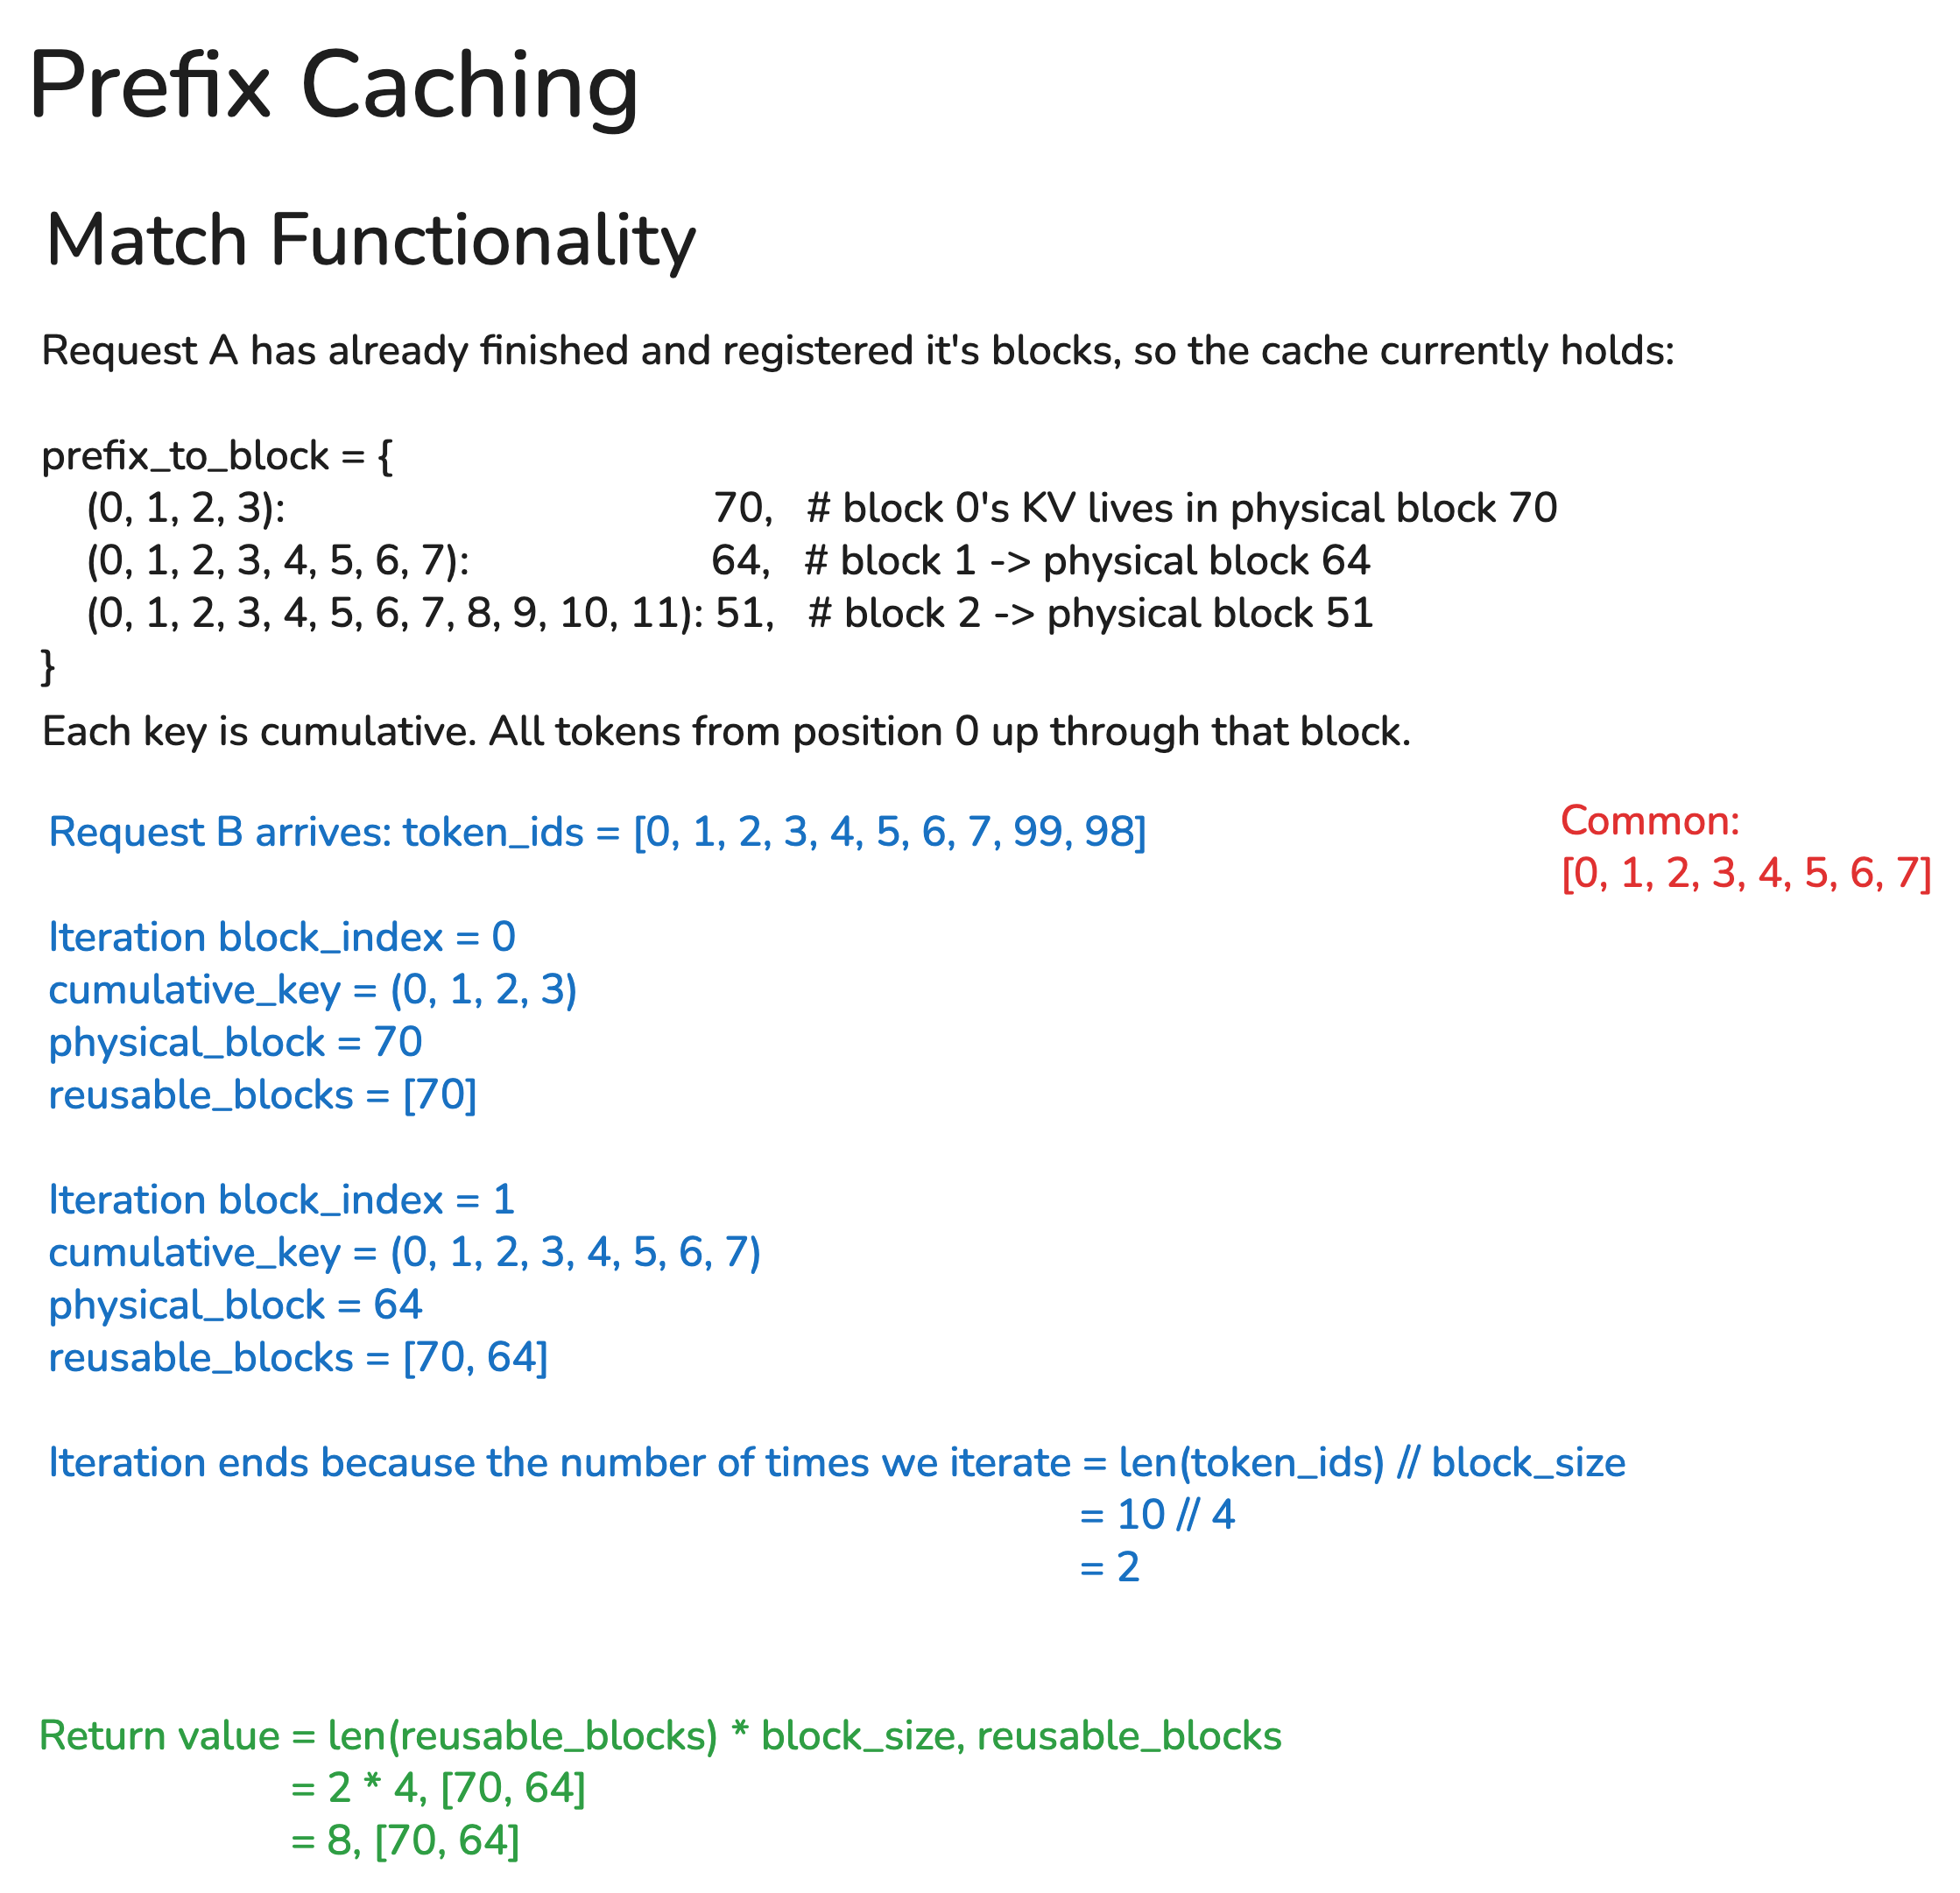

In [57]:
"""
Important points: Why does this class not care about sequence identifiers.
It's only job is the token→block mapping. It takes "here are the tokens, here are the physical blocks that 
hold their KV" and records that. Whether those blocks came from sequence 0, sequence 5, or a hand-built 
test list is irrelevant
"""


class PrefixCache:
    
    def __init__(self, block_size: int):
        self.block_size = block_size
        
        # key   = tuple(prompt_ids[:(block_index+1)*block_size])
        #         i.e. ALL tokens up to and including this block (cumulative prefix)
        # value = physical block id in the PagedKVCache pool
        # Using the cumulative prefix (not just this block's tokens) means a match
        # is a match only if EVERY earlier token is identical too -> collision-free.
        self._prefix_to_block: dict[tuple, int] = {}

        # Concrete example, block_size = 4, tokens [10,11,12,13, 20,21,22,23]:
        # block 0 key = (10,11,12,13)
        # block 1 key = (10,11,12,13, 20,21,22,23) ← includes block 0's tokens too

    def _num_full_blocks(self, token_ids: list[int]) -> int:
        """How many COMPLETELY-filled blocks these tokens make (trailing partial
        block is not cacheable — its contents aren't fixed yet)."""
        
        return len(token_ids) // self.block_size


    def match(self, token_ids: list[int]) -> tuple[int, list[int]]:
        """Return (num_cached_tokens, reusable_physical_block_ids).
        Walk full blocks from the front; STOP at the first miss — a prefix match
        must be contiguous from position 0 (no skipping gaps)."""
        
        reusable_blocks: list[int] = []
        for block_index in range(self._num_full_blocks(token_ids)):
            cumilative_key = tuple(token_ids[: (block_index + 1) * self.block_size])
            physical_block = self._prefix_to_block.get(cumilative_key)
            if physical_block is None: # first mismatch = prefixes diverge here
                break                 # everything after is necessarily new too
            reusable_blocks.append(physical_block)
        return len(reusable_blocks) * self.block_size, reusable_blocks


    def register(self, token_ids: list[int], block_table: list[int], cache: PagedKVCache | None = None) -> None:
        """Publish a filled sequence's full blocks for future reuse, pinning each
        in the cache so it outlives the producing sequence."""

        for block_index in range(self._num_full_blocks(token_ids)):
            cumulative_key = tuple(token_ids[: (block_index + 1) * self.block_size])
            if cumulative_key not in self._prefix_to_block:
                self._prefix_to_block[cumulative_key] = block_table[block_index]
                if cache is not None:
                    cache.pin(block_table[block_index])
        print(self._prefix_to_block)

    def attach_prefix(self, seq_id: int, token_ids: list[int], cache: PagedKVCache) -> int:
        """Adopt any reusable prefix blocks into seq_id's empty block table and
        return the number of already-cached tokens (prefill can skip them)."""
        
        num_cached_tokens, reusable_blocks = self.match(token_ids)
        if reusable_blocks:
            cache.adopt_shared_blocks(seq_id, reusable_blocks)
        return num_cached_tokens

In [61]:
BS = 4
cache = PagedKVCache(n_layer=1, n_head=2, d_head=3, block_size=BS, num_blocks=32)
prefix = PrefixCache(block_size=BS)
shared = list(range(12))            # a 12-token "system prompt" = 3 full blocks

# --- request A: allocate blocks, fill them (pretend), publish to the cache ---
cache.ensure_capacity(seq_id=0, total_length=len(shared))
a_blocks = list(cache.block_tables[0])
prefix.register(shared, cache.block_tables[0], cache)   # publishes + pins 3 blocks
print("A registered blocks:", a_blocks)

# --- request B: same prefix + its own tail; should reuse A's 3 blocks ---
promptB = shared + [99, 98, 97]
n_cached = prefix.attach_prefix(seq_id=1, token_ids=promptB, cache=cache)
assert n_cached == 12                                   # skipped all 3 shared blocks
assert cache.block_tables[1] == a_blocks                # SAME physical blocks reused
print(f"B reused {n_cached} cached tokens -> blocks {cache.block_tables[1]}")

# --- a request that shares tokens but NOT from position 0 reuses nothing ---
n_bad = prefix.attach_prefix(seq_id=2, token_ids=[1, 2, 3] + shared, cache=cache)
assert n_bad == 0
print("non-position-0 overlap reused 0 tokens (APC's exact-prefix limit)")

# --- A finishes: its blocks are pinned by the cache, so they SURVIVE ---
free_before = cache.allocator.num_free
cache.free(seq_id=0)                      # A done; refcount drops but pin keeps them
assert cache.allocator.num_free == free_before   # nothing returned to the pool
# ...and B (still holding the shared blocks) can keep using them
k_still_there = cache.block_tables[1]
assert k_still_there == a_blocks
print("A finished but pinned prefix blocks survived — B still holds them")

print("\nc2 OK — exact-prefix reuse, contiguous-from-0 limit, pinned survival")

{(0, 1, 2, 3): 31, (0, 1, 2, 3, 4, 5, 6, 7): 30, (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11): 29}
A registered blocks: [31, 30, 29]
B reused 12 cached tokens -> blocks [31, 30, 29]
non-position-0 overlap reused 0 tokens (APC's exact-prefix limit)
A finished but pinned prefix blocks survived — B still holds them

c2 OK — exact-prefix reuse, contiguous-from-0 limit, pinned survival
